In [5]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from run_manager import RunViewer
import pl_utils


In [ ]:
rv = RunViewer(exp_path=this_path.parent)
df_base = rv.fetch_results()

df_stats = df_base.pipe(pl_utils.get_stats)

print(df_base.columns)
with pl_utils.Config():
    print(df_base)
    # print(df_stats)


['run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'wd', 'batch_size', 'iters/epoch', 'iters', 'target_steps', 'ndata_per_class', 'fils', 'ensembles', 'base_fils', 'num_params', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'train_loss', 'train_acc', 'train_path_loss', 'train_path_acc', 'val_loss', 'val_acc', 'val_path_loss', 'val_path_acc', 'param_l2norm_layer', 'param_l2norm', 'grad_l2norm_layer', 'grad_l2norm', 'dur_total_core', 'dur_train_core', 'dur_dl_train']
shape: (557, 41)
┌────────┬───────────────────────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬─────────┬────────────┬─────────────┬───────┬──────────────┬─────────────────┬──────┬───────────┬───────────┬────────────┬──────────────────┬───────────┬───────────────────┬────────────────┬────────────────┬────────────────

In [7]:
df = df_stats

df = df.with_columns((pl.col("grad_l2norm") / pl.col("param_l2norm") / 1e-3).alias("wd_ratio (x1e-3)"))
# df = df.with_columns((pl.col("wd") * pl.col("param_l2norm") / pl.col("grad_l2norm") * 1e3).alias("wd_ratio (x1e-3)"))

se_analyze = df_base["param_l2norm"].list.last()
df = df.hstack([se_analyze.alias("param_l2norm_ext")])

# df = df.filter(pl.col("fils").is_in([32, 4]))
# df = df.filter(pl.col("fils").is_in([32, 16, 8, 4]))

df = df.filter(pl.col("base_fils").is_in([64]))


# piv_value = "grad_l2norm"            # 表示する値
# piv_value = "param_l2norm"            # 表示する値
piv_value = "val_acc"                  # 表示する値
# piv_value = "wd_ratio (x1e-3)"               # 表示する値
# piv_value = "param_l2norm_ext"               # 表示する値
# piv_value = "epoch"               # 表示する値

piv_index = ("fils", "ensembles")      # 縦軸

# piv_on = "train_dataset"                        # 横軸
piv_on = "wd"                        # 横軸
ext_column = "train_ndata"           # このカラムの要素ごとにheatmapを表示
# ext_column = "train_ndata"           # このカラムの要素ごとにheatmapを表示

# piv_on = "train_ndata"                        # 横軸
# ext_column = "wd"           # このカラムの要素ごとにheatmapを表示

# agg = "len"
agg = "mean"
# agg = "max"

# 正規化の方向を設定
axis = None    # 0: 行方向, 1: 列方向


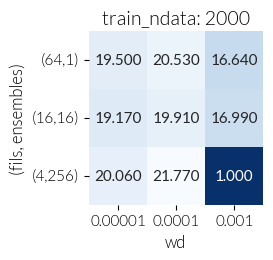

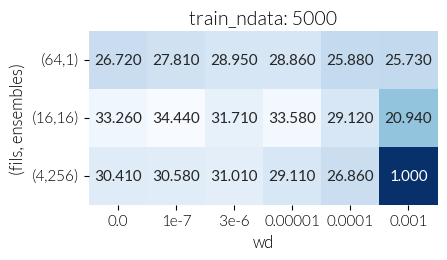

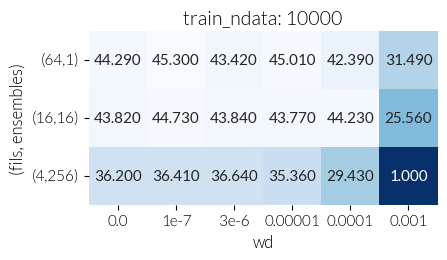

In [8]:
ext_l = df[ext_column].unique()
for i, ext in enumerate(ext_l):
    # pivot table 作成
    df_ext = df.filter(pl.col(ext_column) == ext)
    df_piv = df_ext.pivot(values=piv_value, index=piv_index, on=piv_on, sort_columns=True, aggregate_function=agg)

    # カラムが文字列順になっているため、数字部分をソート
    new_columns = pl.DataFrame({"cols": df_piv.columns}).with_columns(pl.col("cols").cast(pl.Float32, strict=False).alias("numeric")).sort("numeric", maintain_order=True)["cols"].to_list()
    df_piv = df_piv.select(new_columns)


    # (fil, ensemble) の形式に
    df_piv = df_piv.with_columns(("(" + pl.col("fils").cast(pl.String) + "," + pl.col("ensembles").cast(pl.String)).alias("(fils, ensembles)") + ")")
    df_piv = df_piv.select(["(fils, ensembles)"] + new_columns).select(pl.exclude(["fils", "ensembles"]))

    # 0列目がx軸ラベル、1列目以降がy軸ラベルになる df を heat map に変換
    square_size = 0.75
    hm_x = df_piv.columns[1:]
    hm_y = df_piv[df_piv.columns[0]]
    data = df_piv.select(hm_x).to_numpy()
    annot = data.copy()

    # # 正規化の方向を設定
    # axis = 0    # 0: 行方向, 1: 列方向

    if axis:
        # min-max 正規化
        # min_vals = data.min(axis=axis, keepdims=True)
        # max_vals = data.max(axis=axis, keepdims=True)
        # data = (data - min_vals) / (max_vals - min_vals + 1e-8)  # ゼロ除算対策
        
        # Zスコア正規化
        mean_vals = data.mean(axis=axis, keepdims=True)
        std_vals = data.std(axis=axis, keepdims=True)
        data = (data - mean_vals) / (std_vals + 1e-8)  # ゼロ除算対策

    if piv_value[-4:] == "_acc":
        annot *= 100

    fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size))
    
    fontname, fontweight = "Lato", 300 # フォント名とウェイトを指定

    hm_kwargs = {
        "cmap": "Blues_r",
        "cbar": False,
        # "cbar_kws": {"ticks": []},
        "fmt": ".3f",
        "annot_kws": {"size": 11, "fontname": fontname, "fontweight": 500}
    }

    ax = sns.heatmap(data, annot=annot, square=False, **hm_kwargs)
    ax.set_title(f"{ext_column}: {ext}", fontsize=14, fontname=fontname, fontweight=fontweight)
    # ax.set_title(f"{piv_value} ({ext_column}: {ext})", fontsize=14, fontname=fontname, fontweight=fontweight)
    ax.set_xlabel(piv_on, fontsize=12, fontname=fontname, fontweight=fontweight)
    ax.set_ylabel(hm_y.name, fontsize=12, rotation=90, fontname=fontname, fontweight=fontweight)

    ax.set_xticklabels(hm_x, fontsize=11, rotation=0)
    for label in ax.get_xticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    ax.set_yticklabels(hm_y, fontsize=11, rotation=0)
    for label in ax.get_yticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    plt.show()